In [1]:

import numpy as np
from scipy import signal
from matplotlib import pyplot as plt
from matplotlib import patches 


import schemdraw
from schemdraw import flow
import schemdraw as schem
import schemdraw.elements as e
from schemdraw import dsp

%config InlineBackend.figure_formats = ['svg']
%matplotlib inline

from IPython.core.display import HTML
HTML("""
<style>
.jp-RenderedSVG{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")


Finite Impulse Response (FIR) filters are digital filters which have - as the name suggests - a finite impulse response. 
These filters do not have an internal feedback and can be applied simply by convolving an input sequence $x[n]$ with the filter's impulse response $h[n]$ to get the output sequence $y[n]$:

$$
y[n] = x[n] * h[n]
$$


For FIR filters, the impulse response $h[n]$ is a one-dimensional array containing the $N$ filter coefficients. 
The following example shows the coefficients, respectively the impulse response, for a filter of the order $N=5$.
A filter of the order $N$ has $M=N+1$ coefficients, since $b_0$ - the gain of the undelayed signal - is not considered in this case.
The filter order equals the maximum delay of the filter. 


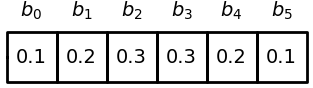

In [2]:
with schemdraw.Drawing() as d:
    d.config(unit=1, fontsize=14)

    dsp.Square().label('0.1').label('$b_0$', loc='top',ofst=0.2)
    dsp.Square().label('0.2').label('$b_1$', loc='top',ofst=0.2)
    dsp.Square().label('0.3').label('$b_2$', loc='top',ofst=0.2)
    dsp.Square().label('0.3').label('$b_3$', loc='top',ofst=0.2)
    dsp.Square().label('0.2').label('$b_4$', loc='top',ofst=0.2)
    dsp.Square().label('0.1').label('$b_5$', loc='top',ofst=0.2)

    d.draw()


-----

# The Difference Equation

The difference equation can be used for calculating the output $y[n]$ of an FIR filter.
It is a sum over the multiplication of all filter coefficients with the respective delayed sample of the input signal $x[n]$.
For the fifth order FIR this results in:

$$
y[n] = b_0 x[n] + b_1 x[n-1]+ b_2 x[n-2]+ b_3 x[n-3]+ b_4 x[n-4] + b_5 x[n-5]
$$


The general form of the difference equation for FIR filters is the following sum equation:

$$
  y[n] =  \sum\limits_{i=0}^{i=N} b_i  x[n-i]
$$

-----

# Implementation Structure 

Another important representation of a filter is the  implementation structure. It can be directly derived from the difference equation and vice versa. 
The signal flow diagram below shows the **direct form** of a fifth order FIR, which is **canonical**.  A canonical implementation of a  filter uses the minimum number of delay elements.

**Each $z^{-1}$ block represents a delay by one sample.** 

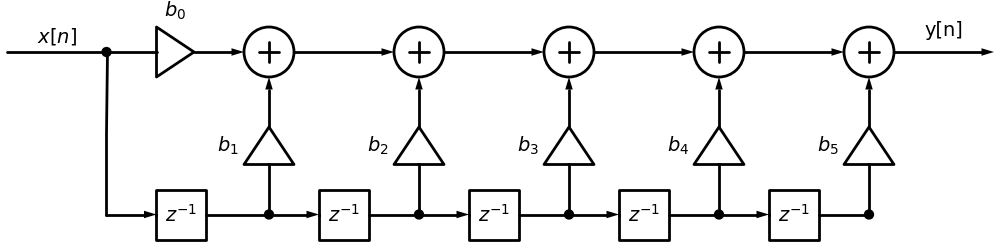

In [3]:
with schemdraw.Drawing() as d:
    d.config(unit=1, fontsize=14)

    e.Line().length(2).label('$x[n]$')
    e.Dot()
    d.push()
    e.Line()
    dsp.Amp().label('$b_0$')
    e.Arrow()
    dsp.Sum()
    e.Arrow().length(2)
    dsp.Sum()
    e.Arrow().length(2)
    dsp.Sum()
    e.Arrow().length(2)
    dsp.Sum()
    e.Arrow().length(2)
    dsp.Sum()
    e.Arrow().label('y[n]').length(2)

    d.pop()
    e.Line().down().length(3.25)
    e.Arrow().right()
    dsp.Square().label('$z^{-1}$')
    e.Line().right().length(1.25)
    e.Dot()
    
    d.push()
    
    e.Line().up().length(1)
    dsp.Amp().label('$b_1$')
    e.Arrow()
    
    d.pop()

    e.Arrow().right()
    dsp.Square().label('$z^{-1}$')
    e.Line().right().length(1)
    e.Dot()
    
    d.push()
    
    e.Line().up().length(1)
    dsp.Amp().label('$b_2$')
    e.Arrow()
    
    d.pop()

    e.Arrow().right()
    dsp.Square().label('$z^{-1}$')
    e.Line().right().length(1)
    e.Dot()
    
    d.push()
    
    e.Line().up().length(1)
    dsp.Amp().label('$b_3$')
    e.Arrow()
    
    d.pop()

    e.Arrow().right()
    dsp.Square().label('$z^{-1}$')
    e.Line().right().length(1)
    e.Dot()
    
    d.push()
    
    e.Line().up().length(1)
    dsp.Amp().label('$b_4$')
    e.Arrow()
    
    d.pop()

    e.Arrow().right()
    dsp.Square().label('$z^{-1}$')
    e.Line().right().length(1)
    e.Dot()
    
    d.push()
    
    e.Line().up().length(1)
    dsp.Amp().label('$b_5$')
    e.Arrow()
    
    d.pop()
    
    

-----

# Exercise

The plot below shows an impulse response $h[n]$ of an FIR filter.

- 1: Determine the order and the coefficients of the filter.
- 2: Write the difference equation.
- 3: Draw the signal flow graph with coefficients.
- 4: Calculate $y[n]$ for $x[n] = [1,1,1,1,1]$

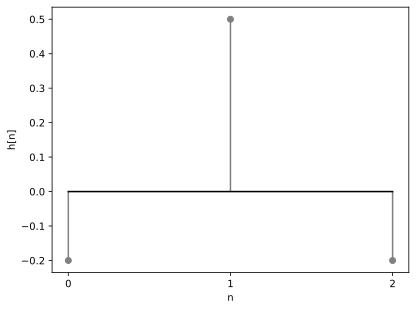

In [4]:
fs = 16000

h = [-0.2, 0.5,  -0.2]

plt.stem(h, 'gray', markerfmt='gray', basefmt='k')
plt.xlabel('n')
plt.ylabel('h[n]')
plt.xticks([0,1,2])
plt.show()

step = np.ones(5)

y = np.convolve(h,step)

#plt.plot(y);
